In [ ]:
import pandas as pd
movies = pd.read_csv("imdb_top_1000.csv")
movies = movies[["Certificate","Runtime","Genre","IMDB_Rating"]]
print(movies)

    Certificate  Runtime                     Genre  IMDB_Rating
0             A  142 min                     Drama          9.3
1             A  175 min              Crime, Drama          9.2
2            UA  152 min      Action, Crime, Drama          9.0
3             A  202 min              Crime, Drama          9.0
4             U   96 min              Crime, Drama          9.0
..          ...      ...                       ...          ...
995           A  115 min    Comedy, Drama, Romance          7.6
996           G  201 min            Drama, Western          7.6
997      Passed  118 min       Drama, Romance, War          7.6
998         NaN   97 min                Drama, War          7.6
999         NaN   86 min  Crime, Mystery, Thriller          7.6

[1000 rows x 4 columns]


In [3]:
group = movies.groupby("Certificate")
output = group["Certificate"].count()
print(output)

Certificate
16            1
A           197
Approved     11
G            12
GP            2
PG           37
PG-13        43
Passed       34
R           146
TV-14         1
TV-MA         1
TV-PG         3
U           234
U/A           1
UA          175
Unrated       1
Name: Certificate, dtype: int64


In [4]:
movies = movies.fillna({"Certificate": "Unrated"})
group = movies.groupby("Certificate")
output = group["Certificate"].count()
print(output)
print(output[output >= 10])

Certificate
16            1
A           197
Approved     11
G            12
GP            2
PG           37
PG-13        43
Passed       34
R           146
TV-14         1
TV-MA         1
TV-PG         3
U           234
U/A           1
UA          175
Unrated     102
Name: Certificate, dtype: int64
Certificate
A           197
Approved     11
G            12
PG           37
PG-13        43
Passed       34
R           146
U           234
UA          175
Unrated     102
Name: Certificate, dtype: int64


In [5]:
keep_rows = output[output >= 10].index
movies = movies[movies["Certificate"].isin(keep_rows)]
print(movies)

    Certificate  Runtime                     Genre  IMDB_Rating
0             A  142 min                     Drama          9.3
1             A  175 min              Crime, Drama          9.2
2            UA  152 min      Action, Crime, Drama          9.0
3             A  202 min              Crime, Drama          9.0
4             U   96 min              Crime, Drama          9.0
..          ...      ...                       ...          ...
995           A  115 min    Comedy, Drama, Romance          7.6
996           G  201 min            Drama, Western          7.6
997      Passed  118 min       Drama, Romance, War          7.6
998     Unrated   97 min                Drama, War          7.6
999     Unrated   86 min  Crime, Mystery, Thriller          7.6

[991 rows x 4 columns]


In [6]:
movies = movies.copy()
movies[["Runtime_in_nums","Time"]] = movies["Runtime"].str.split(" ", n=1, expand=True)
print(movies)

    Certificate  Runtime                     Genre  IMDB_Rating  \
0             A  142 min                     Drama          9.3   
1             A  175 min              Crime, Drama          9.2   
2            UA  152 min      Action, Crime, Drama          9.0   
3             A  202 min              Crime, Drama          9.0   
4             U   96 min              Crime, Drama          9.0   
..          ...      ...                       ...          ...   
995           A  115 min    Comedy, Drama, Romance          7.6   
996           G  201 min            Drama, Western          7.6   
997      Passed  118 min       Drama, Romance, War          7.6   
998     Unrated   97 min                Drama, War          7.6   
999     Unrated   86 min  Crime, Mystery, Thriller          7.6   

    Runtime_in_nums Time  
0               142  min  
1               175  min  
2               152  min  
3               202  min  
4                96  min  
..              ...  ...  
995   

In [7]:
group = movies.groupby("Genre")
output = group["Genre"].count()
print(output)

Genre
Action, Adventure                5
Action, Adventure, Biography     1
Action, Adventure, Comedy       10
Action, Adventure, Crime         1
Action, Adventure, Drama        14
                                ..
Mystery, Romance, Thriller       1
Mystery, Sci-Fi, Thriller        2
Mystery, Thriller                9
Thriller                         1
Western                          4
Name: Genre, Length: 200, dtype: int64


In [8]:
genre_dummies = movies["Genre"].str.get_dummies(sep = ", ")
movies = pd.concat([movies, genre_dummies],axis=1)
print(movies)

    Certificate  Runtime                     Genre  IMDB_Rating  \
0             A  142 min                     Drama          9.3   
1             A  175 min              Crime, Drama          9.2   
2            UA  152 min      Action, Crime, Drama          9.0   
3             A  202 min              Crime, Drama          9.0   
4             U   96 min              Crime, Drama          9.0   
..          ...      ...                       ...          ...   
995           A  115 min    Comedy, Drama, Romance          7.6   
996           G  201 min            Drama, Western          7.6   
997      Passed  118 min       Drama, Romance, War          7.6   
998     Unrated   97 min                Drama, War          7.6   
999     Unrated   86 min  Crime, Mystery, Thriller          7.6   

    Runtime_in_nums Time  Action  Adventure  Animation  Biography  ...  \
0               142  min       0          0          0          0  ...   
1               175  min       0          0    

In [9]:
movies_encoded = pd.get_dummies(movies, columns= ["Certificate"])
print(movies_encoded)

     Runtime                     Genre  IMDB_Rating Runtime_in_nums Time  \
0    142 min                     Drama          9.3             142  min   
1    175 min              Crime, Drama          9.2             175  min   
2    152 min      Action, Crime, Drama          9.0             152  min   
3    202 min              Crime, Drama          9.0             202  min   
4     96 min              Crime, Drama          9.0              96  min   
..       ...                       ...          ...             ...  ...   
995  115 min    Comedy, Drama, Romance          7.6             115  min   
996  201 min            Drama, Western          7.6             201  min   
997  118 min       Drama, Romance, War          7.6             118  min   
998   97 min                Drama, War          7.6              97  min   
999   86 min  Crime, Mystery, Thriller          7.6              86  min   

     Action  Adventure  Animation  Biography  Comedy  ...  Certificate_A  \
0         0

In [10]:
from sklearn.model_selection import train_test_split

x = movies_encoded.drop(columns=["Runtime","Genre","IMDB_Rating","Time"])
y = movies_encoded["IMDB_Rating"]

X_train,X_test,y_train,y_test = train_test_split(x, y, test_size= 0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(792, 32)
(199, 32)
(792,)
(199,)


In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](32,)","[ 0. ,-0.06,-0.06,..., 0.01,-0.04,-0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](32,)","['Runtime_in_nums','Action','Adventure',...,'Certificate_U', 'Certificate_UA','Certificate_Unrated']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.688
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,32
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,31


In [12]:
print("Intercept: ", model.intercept_)
print("Coefficients: ", model.coef_)

Intercept:  7.688363046065509
Coefficients:  [ 0.00275439 -0.06013158 -0.05639358  0.04222831 -0.0291395  -0.02807745
 -0.00324486 -0.00303445 -0.07530188  0.0027459   0.0102593  -0.08350644
 -0.03451097 -0.01274801 -0.12899885 -0.00719778 -0.03126178  0.04909376
 -0.06958352 -0.05106037  0.02760994 -0.05860373  0.01613085  0.05433039
  0.09163436  0.00035924 -0.15143937  0.1329335  -0.09894289  0.0103918
 -0.04418486 -0.01121301]


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model Performance
y_pred = model.predict(X_test)

# Accuracy of the model
print('Mean squared error: ', mean_squared_error(y_test, y_pred))
print('Mean absolute error: ', mean_absolute_error(y_test, y_pred))

# Prediction details
residuals = y_test - y_pred
ssr = sum(residuals ** 2)
print("\nPredicted Values: ", y_pred)
print("\nSum of squared residuals: ", ssr)

r2 = r2_score(y_test, y_pred, multioutput='raw_values')
print("\nR² for each output:", r2)

Mean squared error:  0.06308505556315466
Mean absolute error:  0.20556220809906106

Predicted Values:  [7.89066277 7.98347084 7.66741902 8.14550111 7.90314069 7.8769982
 7.94095644 8.16646108 8.02316338 7.84608108 7.99173317 7.9113681
 7.99354641 7.98240734 7.86673776 7.93470564 8.07016907 7.95822852
 7.90275727 7.97350422 8.01846988 8.07112278 7.89527772 7.96092883
 8.16794612 7.96729976 8.04642667 7.95641559 7.96789228 7.94833064
 7.90770688 8.16598808 8.03398749 8.01113687 7.95437969 8.04103215
 7.87559678 7.98847275 8.1015145  8.03354703 7.8790778  7.95358659
 7.97312025 7.93584322 8.06947687 7.95565712 7.80053164 7.99338328
 7.76370938 7.95461079 8.49719957 8.03838996 7.87559678 8.15593399
 8.20425365 8.05103686 7.78947117 7.96224955 7.97167387 7.93676831
 8.03749517 8.05959633 7.87761649 7.94534599 7.97507271 7.95154921
 7.76829658 8.05916719 7.94680506 7.87921803 7.89988734 8.02055289
 8.06248474 8.06228469 7.97062472 8.01337681 7.93195125 7.86032781
 8.12731159 8.0761338  7.963

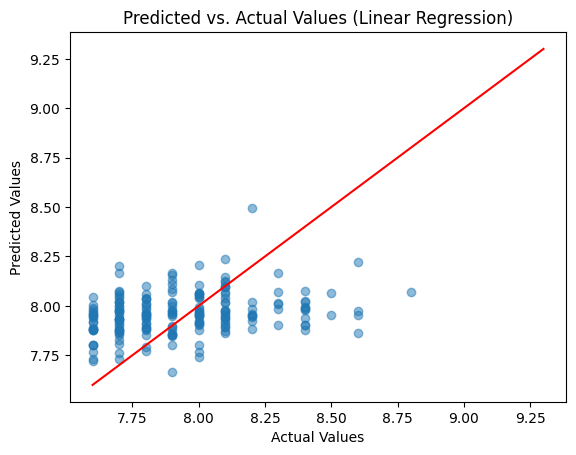

In [14]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs. Actual Values (Linear Regression)")
plt.show()

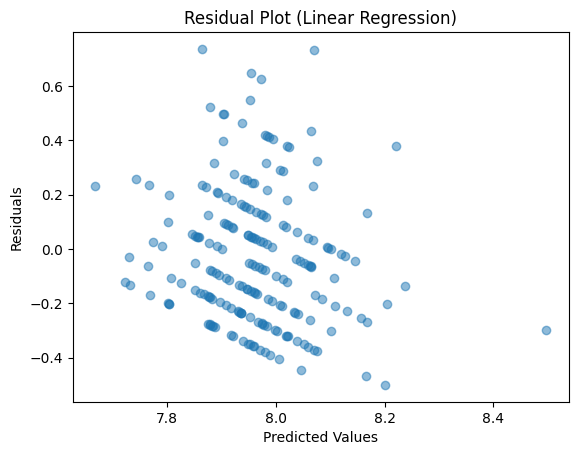

In [15]:
# Plot the residuals
plt.scatter(y_pred, y_test - y_pred, alpha=0.5)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Linear Regression)")
plt.show()

In [16]:
print(X_train.columns.to_list())

['Runtime_in_nums', 'Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Sport', 'Thriller', 'War', 'Western', 'Certificate_A', 'Certificate_Approved', 'Certificate_G', 'Certificate_PG', 'Certificate_PG-13', 'Certificate_Passed', 'Certificate_R', 'Certificate_U', 'Certificate_UA', 'Certificate_Unrated']


In [26]:
second_chances = pd.DataFrame(0, index=[0], columns=X_train.columns)
second_chances["Runtime_in_nums"] = 120
second_chances["Drama"] = 1
second_chances["Comedy"] = 1
second_chances["Certificate_PG-13"] = True

second_chances_pred = model.predict(second_chances)
print(second_chances_pred)

[7.83633872]


In [22]:
print(y_test.describe())

count    199.000000
mean       7.931658
std        0.256536
min        7.600000
25%        7.700000
50%        7.900000
75%        8.100000
max        8.800000
Name: IMDB_Rating, dtype: float64
